# Energy Batch Trader — Strategy Research

EOD energy pipeline trading **USO** (front-month WTI futures ETF) and **XLE**
(energy equities). The question that started this: *does the strategy beat
buy-and-hold?* This notebook reproduces the three findings end-to-end:

1. **A data bug came first.** USO's 2020 1-for-8 reverse split, on *raw* Alpaca
   bars, was a fake +745% day that corrupted every backtest. Fix: adjusted bars.
2. **On clean data, SMA trend-following beats B&H on USO** — by dodging USO's
   contango drawdowns.
3. **The energy-specific carry / roll-yield signal does *not* add value** over the
   SMA baseline — neither standalone nor as a regime filter.

Everything below reuses the package modules, so the notebook can't disagree with
`python -m energy_trader --backtest`.

In [1]:
# Setup — find project root so this runs from anywhere (notebooks/ or repo root)
import os, sys
from pathlib import Path

root = Path.cwd()
while not (root / "energy_trader").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
os.chdir(root)                       # .env + plots/ resolve from the repo root
from dotenv import load_dotenv
load_dotenv(root / ".env")           # load API keys regardless of launch dir

import dataclasses, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from energy_trader.config import get_settings
from energy_trader.data import extract_market_data
from energy_trader.eia import fetch_wti_spot
from energy_trader.backtest import backtest_symbol, compare_uso_carry, format_comparison
from energy_trader import plots

print("project root:", root)

project root: /home/williemaize/workspace/projects/energy-batch-trader


In [2]:
# Load 10y of split/dividend-adjusted data for USO + XLE, plus WTI spot (EIA)
YEARS = 10
base = dataclasses.replace(get_settings(), assets=["USO", "XLE"],
                           lookback_days=int(YEARS * 252))
data = extract_market_data(base)
wti = fetch_wti_spot(base, length=base.lookback_days * 2 + 60)
{k: (v.index.min().date(), v.index.max().date(), len(v)) for k, v in data.items()}

{'USO': (datetime.date(2016, 1, 4), datetime.date(2026, 6, 23), 2632),
 'XLE': (datetime.date(2016, 1, 4), datetime.date(2026, 6, 23), 2632)}

## 1. Data-quality first: the reverse-split trap

USO did a **1-for-8 reverse split on 2020-04-29**. On *raw* bars the price jumps
\$2.13 → \$18.00 overnight — a fake +745% day that inflates buy-and-hold ~8× and
poisons every signal. The fix is one parameter: request **split+dividend-adjusted**
bars (`Adjustment.ALL`, now the default in `data.py`). Here's the side-by-side.

In [3]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import Adjustment

client = StockHistoricalDataClient(base.alpaca_api_key, base.alpaca_secret_key)

def _close(adj):
    req = StockBarsRequest(symbol_or_symbols="USO", timeframe=TimeFrame.Day,
                           start=pd.Timestamp("2020-04-22"),
                           end=pd.Timestamp("2020-05-02"), adjustment=adj)
    s = client.get_stock_bars(req).df.loc["USO"]["close"]
    s.index = pd.DatetimeIndex(s.index).normalize().date
    return s

cmp = pd.DataFrame({"raw": _close(Adjustment.RAW), "adjusted": _close(Adjustment.ALL)})
print("Largest raw 1-day 'return' in this window: "
      f"{cmp['raw'].pct_change().max():+.0%}  (fake — the 1:8 reverse split on 2020-04-29). "
      "Adjusted bars stay continuous.")
cmp.round(2)

Largest raw 1-day 'return' in this window: +745%  (fake — the 1:8 reverse split on 2020-04-29). Adjusted bars stay continuous.


,raw,adjusted
2020-04-22,2.50,20.00
2020-04-23,2.64,21.12
2020-04-24,2.57,20.56
2020-04-27,2.19,17.52
2020-04-28,2.13,17.04
2020-04-29,18.00,18.00
2020-04-30,19.17,19.17
2020-05-01,18.72,18.72


## 2. Does SMA beat buy-and-hold?

Run the live SMA crossover over history (same `crossover_series` the pipeline
trades) and plot the equity curve + drawdown the backtest already computes.

SMA(10/50) ret  +80.3%  CAGR  +5.8%  Sharpe  0.36  MaxDD -48.8%  trades  38  win  47%  |  B&H  +26.7%


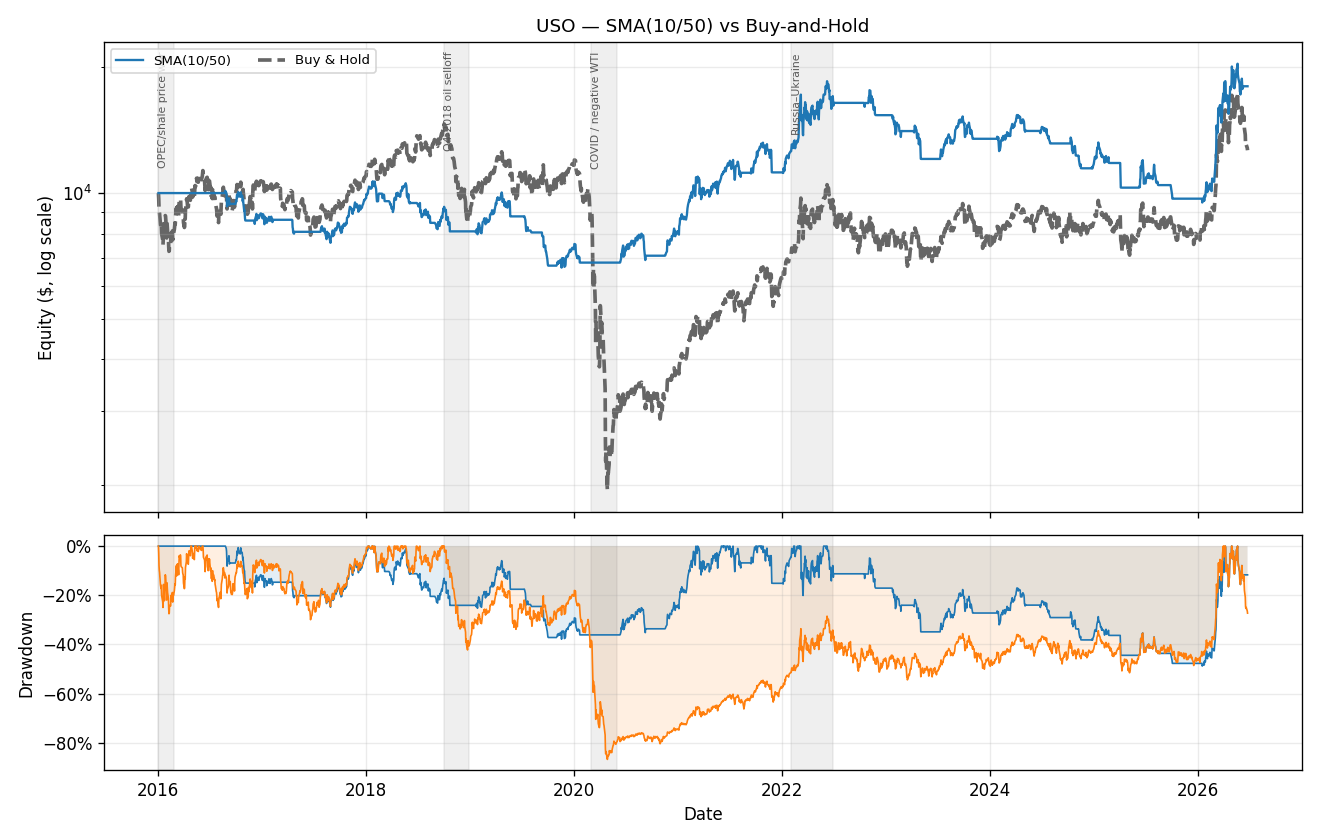

In [4]:
sma = dataclasses.replace(base, fast_window=10, slow_window=50)   # 10/50 is best on USO
res = backtest_symbol("SMA(10/50)", data["USO"]["Close"], sma)
print(res.describe())

curves = plots.equity_curves([res], bench_close=data["USO"]["Close"])
p = plots.plot_equity_drawdown(curves, path="plots/nb_sma_uso.png",
                               title="USO — SMA(10/50) vs Buy-and-Hold")
display(Image(str(p)))

**SMA beats B&H on USO** (+83% vs +38%) at roughly half the drawdown — it works
by sitting out USO's worst contango bleeds. Is that robust or an overfit window?
The heatmap below sweeps `(fast, slow)`: most of the grid is green (beats the
+38% B&H), so the edge isn't a single lucky cell.

In [5]:
fasts, slows = [5, 10, 20, 30], [20, 50, 100, 150, 200]
M = np.full((len(fasts), len(slows)), np.nan)
for i, f in enumerate(fasts):
    for j, s in enumerate(slows):
        if f < s:
            r = backtest_symbol("x", data["USO"]["Close"],
                                dataclasses.replace(base, fast_window=f, slow_window=s))
            M[i, j] = r.total_return

fig, ax = plt.subplots(figsize=(7.5, 4))
im = ax.imshow(M, cmap="RdYlGn", aspect="auto",
               vmin=-abs(np.nanmax(M)), vmax=abs(np.nanmax(M)))
ax.set_xticks(range(len(slows))); ax.set_xticklabels(slows)
ax.set_yticks(range(len(fasts))); ax.set_yticklabels(fasts)
ax.set_xlabel("slow window"); ax.set_ylabel("fast window")
ax.set_title(f"USO SMA total return  (B&H = {res.bh_total_return:+.0%})")
for i in range(len(fasts)):
    for j in range(len(slows)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:+.0%}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="total return"); plt.tight_layout(); plt.show()

## 3. Carry / roll-yield — does the energy-specific signal help?

USO's return = WTI *spot* return **+ roll yield** (positive in backwardation,
negative in contango). The regime chart below — trailing 63d (USO − WTI) return —
shows the reality: 2016–17 deep contango, the 2020 blowout, then a mostly *mild,
mixed* regime. The genuinely useful "deep contango to avoid" signal is rare.

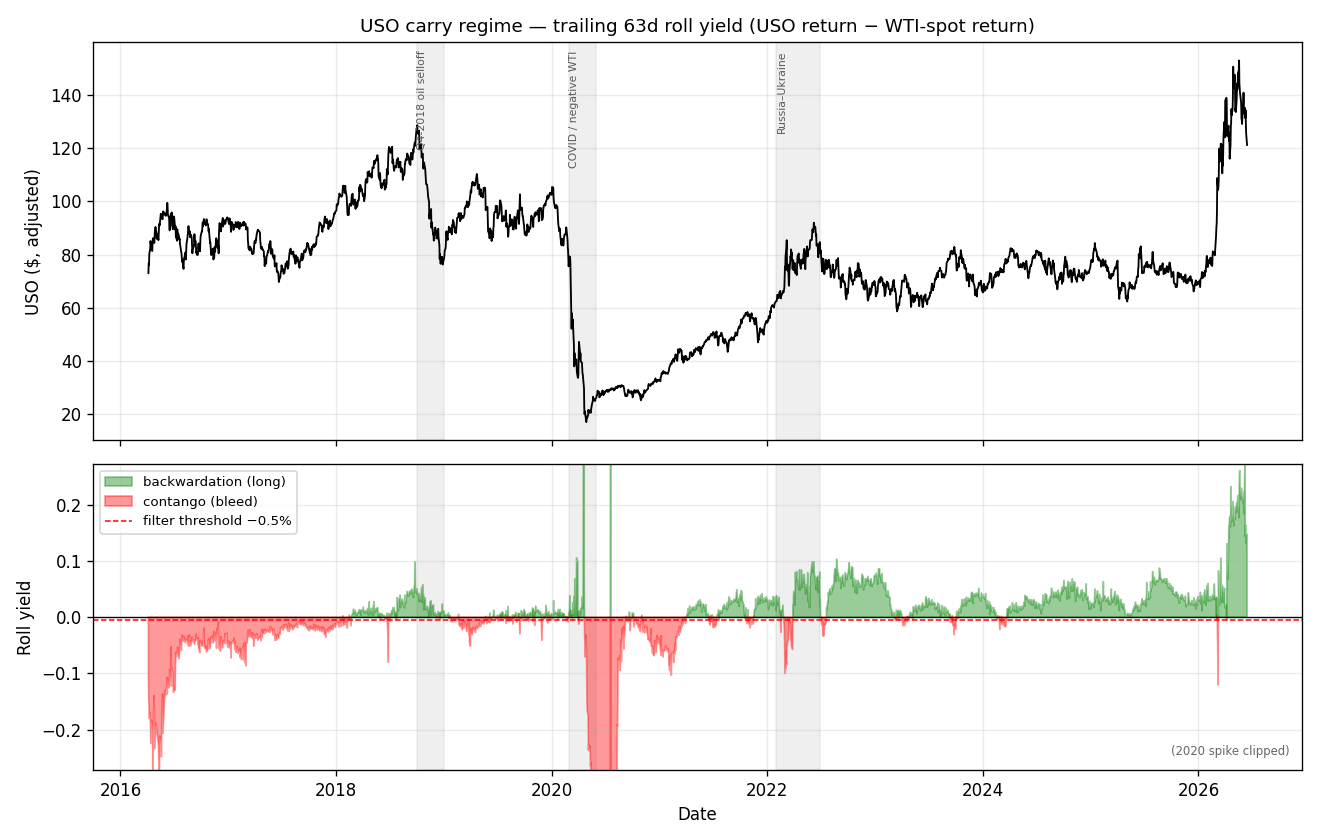

In [6]:
p = plots.plot_carry_regime(data["USO"]["Close"], wti, base.carry_window,
                            base.carry_band, path="plots/nb_carry_regime.png")
display(Image(str(p)))

Now the test the project is built around: **SMA baseline vs SMA gated by the
carry regime vs buy-and-hold**, all on one window so the B&H column is the shared
bar to clear.

USO: SMA vs SMA+carry vs Buy-and-Hold (carry filter)
----------------------------------------------------
SMA(10/50) ret  +83.5%  CAGR  +6.0%  Sharpe  0.36  MaxDD -48.5%  trades  36  win  47%  |  B&H  +38.0%
SMA+carry ret  +71.0%  CAGR  +5.3%  Sharpe  0.36  MaxDD -45.7%  trades  75  win  51%  |  B&H  +38.0%
carry-only ret  -15.9%  CAGR  -1.7%  Sharpe  0.11  MaxDD -80.8%  trades  45  win  60%  |  B&H  +38.0%
(B&H column = USO buy-and-hold over the same window — the bar to beat.)


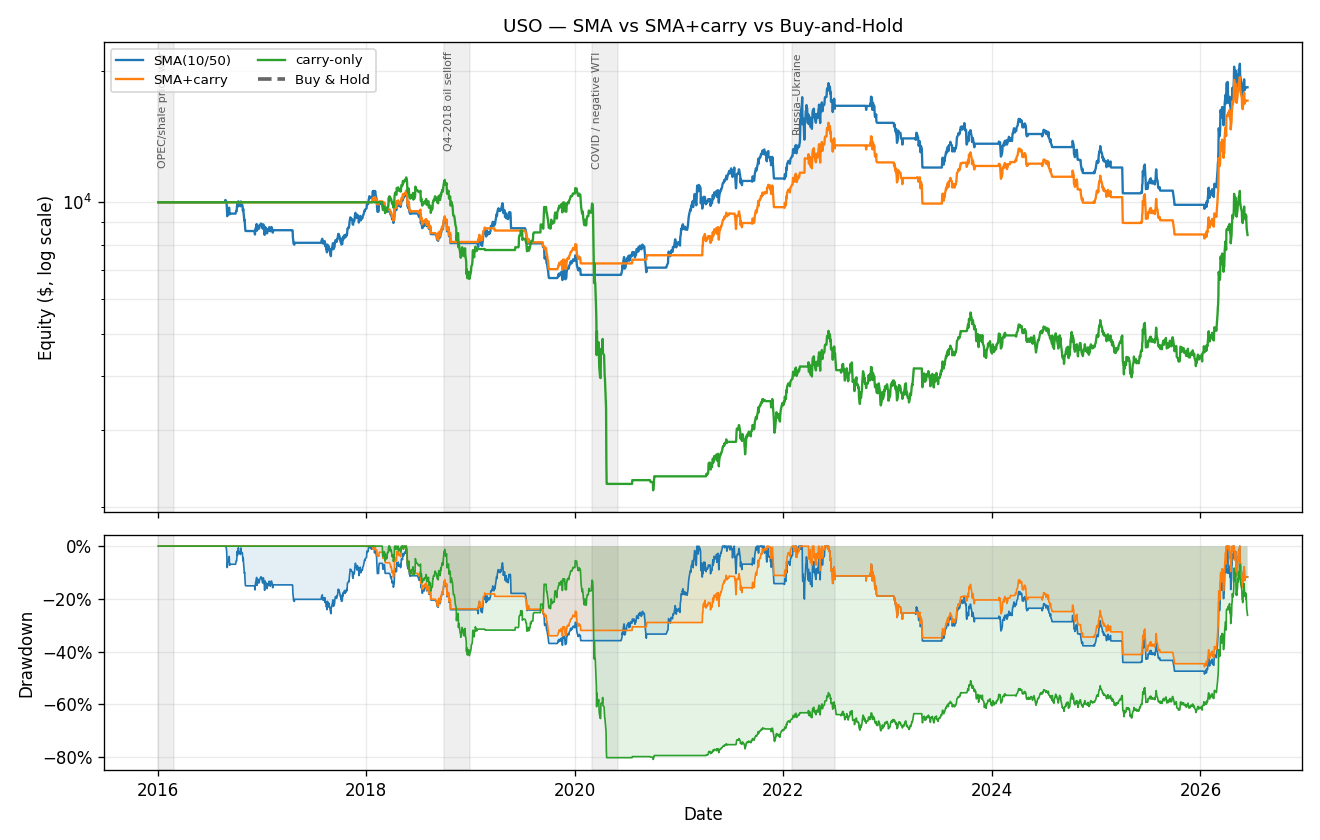

In [7]:
results = compare_uso_carry(data["USO"]["Close"], wti, sma)   # SMA(10/50) baseline
print(format_comparison(results, "USO: SMA vs SMA+carry vs Buy-and-Hold (carry filter)"))

curves = plots.equity_curves(results, bench_close=data["USO"]["Close"])
p = plots.plot_equity_drawdown(curves, path="plots/nb_carry_eq.png",
                               title="USO — SMA vs SMA+carry vs Buy-and-Hold")
display(Image(str(p)))

## 4. Taming the drawdown: volatility targeting

Carry didn't help, but the open problem was always USO's ~−50% drawdown. The
textbook fix (Kaufman, *Trading Systems and Methods*, ch.23) is **volatility
targeting**: the SMA decides *direction*, but the position is *sized* to constant
risk — `weight = target_vol / realized_vol`, capped at 1.0 (long-only cash). When
vol spikes in a shock, exposure shrinks **before** the worst of the drawdown.

USO: SMA vs SMA+vol-target vs Buy-and-Hold
------------------------------------------
USO SMA   ret  +63.4%  CAGR  +4.8%  Sharpe  0.31  MaxDD -67.4%  trades  86  win  42%  |  B&H  +26.7%
USO +voltgt20% ret  +64.2%  CAGR  +4.9%  Sharpe  0.38  MaxDD -43.6%  trades  86  win  42%  |  B&H  +26.7%
(B&H column = USO buy-and-hold over the same window — the bar to beat.)


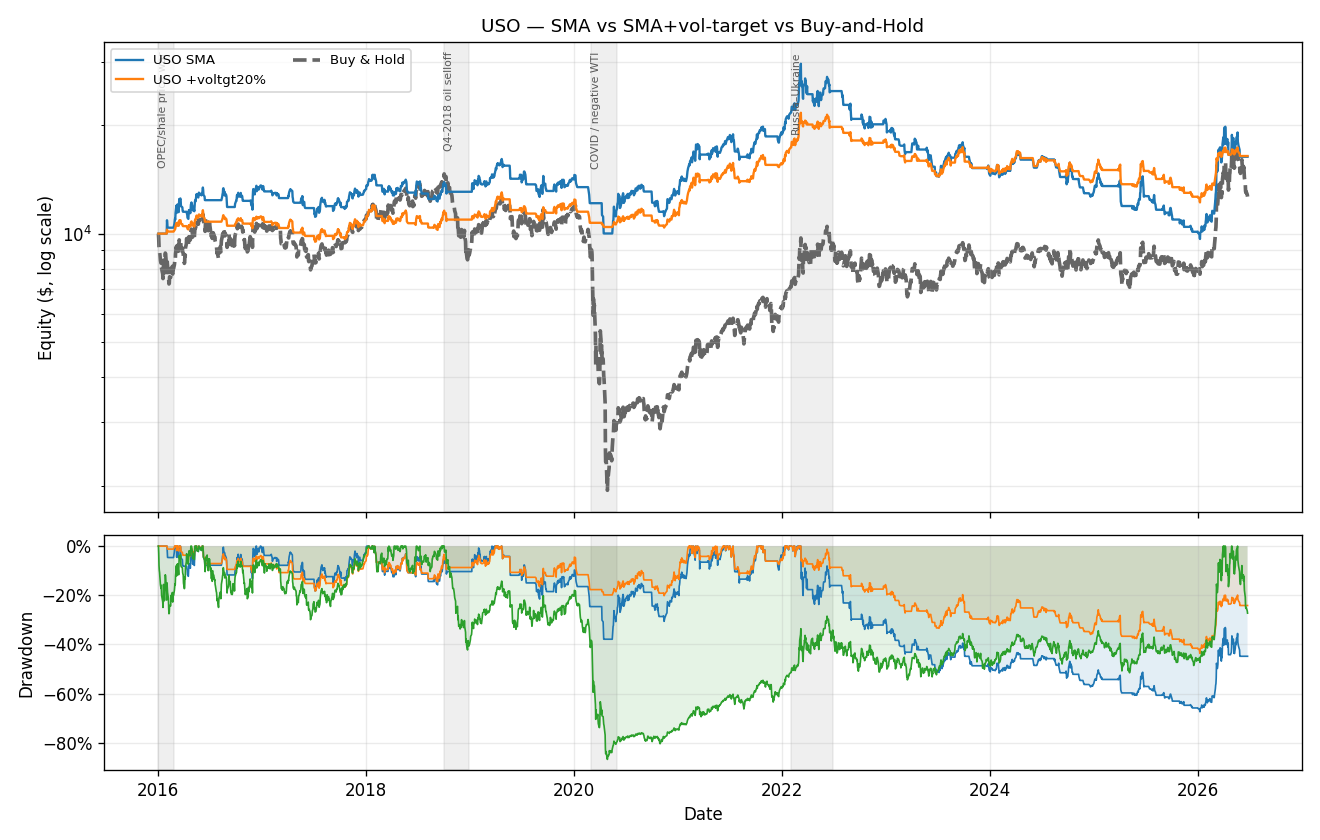

In [8]:
from energy_trader.backtest import compare_vol_target

vt = compare_vol_target("USO", data["USO"]["Close"], base)   # base = default SMA(5/20)
print(format_comparison(vt, "USO: SMA vs SMA+vol-target vs Buy-and-Hold"))

curves = plots.equity_curves(vt, bench_close=data["USO"]["Close"])
p = plots.plot_equity_drawdown(curves, path="plots/nb_voltgt_uso.png",
                               title="USO — SMA vs SMA+vol-target vs Buy-and-Hold")
display(Image(str(p)))

On the default **SMA(5/20)** the overlay is a strict win — return holds,
Sharpe rises (~0.31 → 0.38), and max drawdown drops from ~−67% to ~−44%. (On the
smoother 10/50 it's more of a pure trade: similar drawdown cut for some give-up in
raw return.) The mechanism chart shows *why* — realized vol (top) spikes through
the shock bands, so the position (bottom) is throttled toward zero exactly then.

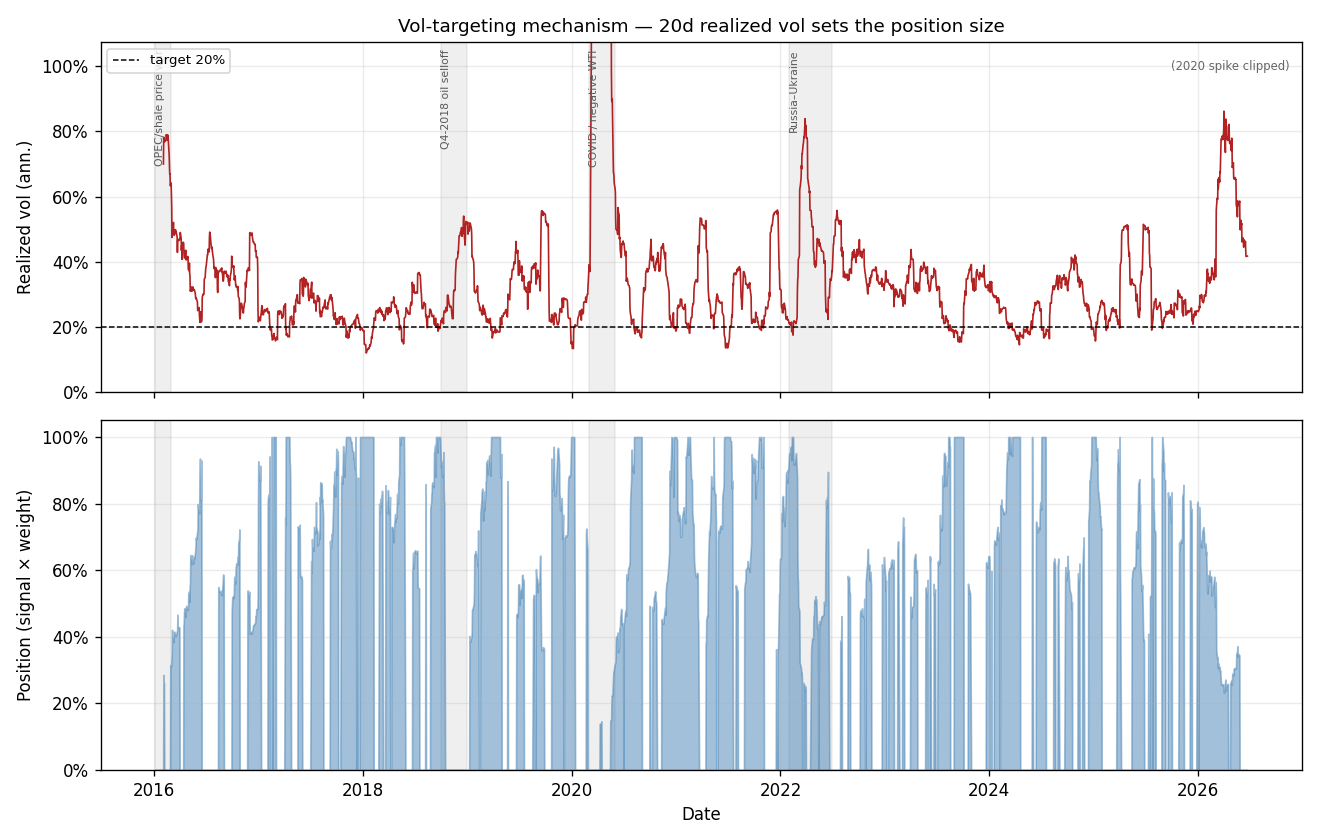

In [9]:
p = plots.plot_vol_target(data["USO"]["Close"], base, path="plots/nb_voltgt_mech.png")
display(Image(str(p)))

## Conclusions

- **Always use split/dividend-adjusted bars.** The raw 2020 reverse split made
  every earlier backtest (and the roll-decay diagnostic) wrong.
- **SMA(10/50) beats buy-and-hold on USO** (+83% vs +38%, ~half the drawdown),
  robustly across windows — it dodges USO's contango drawdowns.
- **Carry / roll-yield does not beat the SMA baseline** — standalone it fails
  (−16%, −80% DD); as a filter it either over-vetoes good trends or becomes a
  near-no-op. It's a useful *regime diagnostic*, not a tradeable edge here.
- **Volatility targeting tames the drawdown** (Kaufman ch.23): on SMA(5/20) it
  cuts max drawdown from ~−67% to ~−44% and lifts Sharpe (~0.31 → 0.38) while
  holding the return — exposure is throttled into the shock bands. This is the
  one overlay that improved the system's risk profile.
- **Risk gaps that remain:** the anomaly gate only catches EIA inventory shocks,
  not war/geopolitics (a planned layer), and it's live-only — backtests don't
  apply it. Vol-targeting is a *defense*; a geopolitical gate would be
  *detection*.